## Análisis de Correlación: IPC vs Actividad Empresarial

### Objetivo
Analizar la **correlación estadística** entre el IPC nacional (índice general) y la actividad empresarial (sociedades constituidas y disueltas) a nivel nacional en España, cubriendo el periodo **enero 2008 – abril 2026**.

### Metodología
1. **Preparación de datos**: Agregación de empresas a nivel nacional y unión con el IPC.
2. **Correlación directa**: Comparación de coeficientes de Pearson y Spearman.
3. **Matriz de correlación**: Visualización heatmap de las tres variables.
4. **Análisis de lag**: Evaluación de correlaciones con desfases de 1-3 meses.
5. **Visualización**: Scatter plots con línea de tendencia.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from correlation.correlation import comparar_correlaciones, matriz_correlacion_visual

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

### 1. Preparación de datos

In [2]:
df_ipc = pd.read_csv('../files/data_processed/ipc.csv')
df_const = pd.read_csv('../files/data_processed/empresas_constituidas.csv')
df_dis = pd.read_csv('../files/data_processed/empresas_disueltas.csv')

# 1. IPC Nacional, Índice General, medida=índice
ipc_nacional = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 2. Constituidas nacionales: sumar todas las CCAA por periodo
const_nacional = (
    df_const
    .groupby('id_tiempo')['numero_sociedades']
    .sum()
    .reset_index()
    .rename(columns={'numero_sociedades': 'constituidas'})
)

# 3. Disueltas nacionales: sumar todas las CCAA por periodo
dis_nacional = (
    df_dis
    .groupby('id_tiempo')['numero_sociedades']
    .sum()
    .reset_index()
    .rename(columns={'numero_sociedades': 'disueltas'})
)

# 4. Merge de las tres fuentes
df_corr = (
    ipc_nacional
    .merge(const_nacional, on='id_tiempo', how='inner')
    .merge(dis_nacional, on='id_tiempo', how='inner')
    .sort_values('id_tiempo')
    .reset_index(drop=True)
)

print(f'Registros totales IPC:       {len(ipc_nacional)}')
print(f'Registros totales const.:    {len(const_nacional)}')
print(f'Registros totales dis.:      {len(dis_nacional)}')
print(f'Registros tras merge:        {len(df_corr)}')
print(f'Periodo: {df_corr["id_tiempo"].min()} – {df_corr["id_tiempo"].max()}')
df_corr.head(10)

Registros totales IPC:       293
Registros totales const.:    220
Registros totales dis.:      220
Registros tras merge:        220
Periodo: 200801 – 202604


,id_tiempo,valor_ipc,constituidas,disueltas
0,200801,71.442,11764,2495
1,200802,71.553,11930,1929
2,200803,72.188,9757,1066
3,200804,72.965,11118,1193
4,200805,73.458,9487,1088
5,200806,73.881,8250,835
6,200807,73.526,8104,1061
7,200808,73.368,5806,741
8,200809,73.353,7337,1198
9,200810,73.605,6902,1266


### 2. Resumen descriptivo

In [3]:
df_corr[['valor_ipc', 'constituidas', 'disueltas']].describe().round(2)

,valor_ipc,constituidas,disueltas
count,220.00,220.00,220.00
mean,82.85,8109.33,1853.25
std,8.33,1772.33,691.21
min,71.44,2314.00,404.00
25%,77.86,6850.50,1368.50
50%,79.91,8023.50,1664.00
75%,85.32,9029.25,2201.75
max,102.88,14307.00,4157.00


### 3. Correlación directa: IPC vs Constituidas

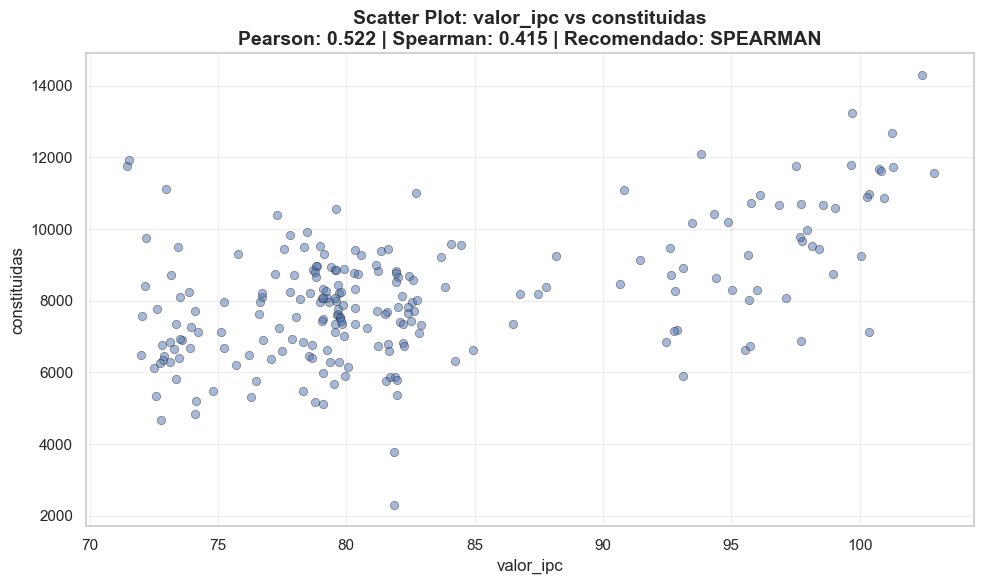


⚠️  USAR SPEARMAN (r = 0.415)
   
   Razón: Hay una diferencia notable entre Pearson y Spearman (0.107).
   Esto sugiere presencia de outliers o relación no lineal.
   Spearman es más robusto en estos casos.
   
   Pearson: 0.522
   Spearman: 0.415
   
   Datos utilizados: 220/220 (100.0%)
        
   Fuerza de la relación: moderada positiva


In [4]:
result_const = comparar_correlaciones(df_corr, 'valor_ipc', 'constituidas')
print(result_const['interpretacion'])

### 4. Correlación directa: IPC vs Disueltas

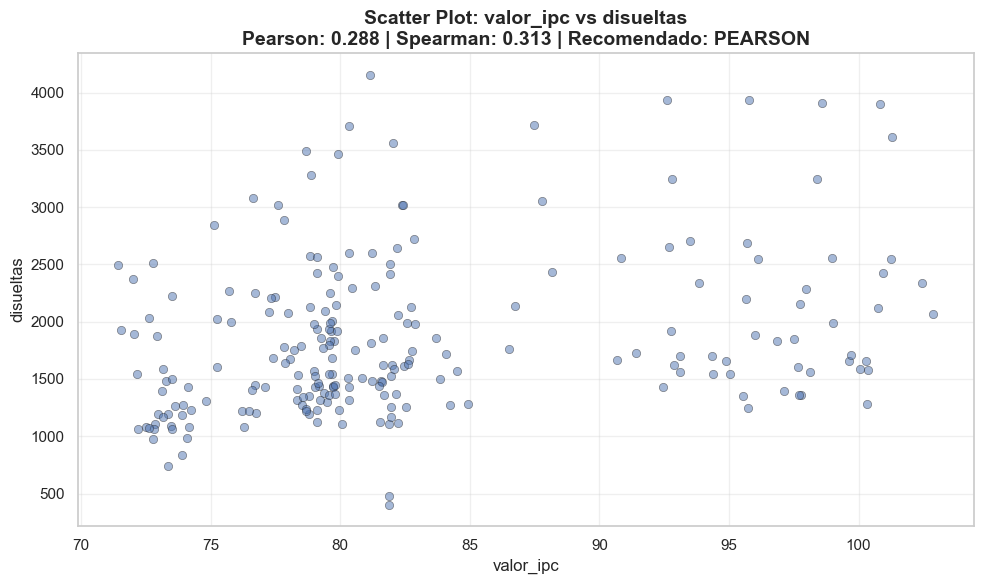


✅ USAR PEARSON (r = 0.288)
   
   Razón: La diferencia entre Pearson y Spearman es pequeña (0.025).
   Esto indica una relación aproximadamente lineal sin outliers significativos.
   
   Pearson: 0.288
   Spearman: 0.313
   
   Datos utilizados: 220/220 (100.0%)
        
   Fuerza de la relación: débil positiva


In [5]:
result_dis = comparar_correlaciones(df_corr, 'valor_ipc', 'disueltas')
print(result_dis['interpretacion'])

### 5. Matriz de correlación (heatmap)

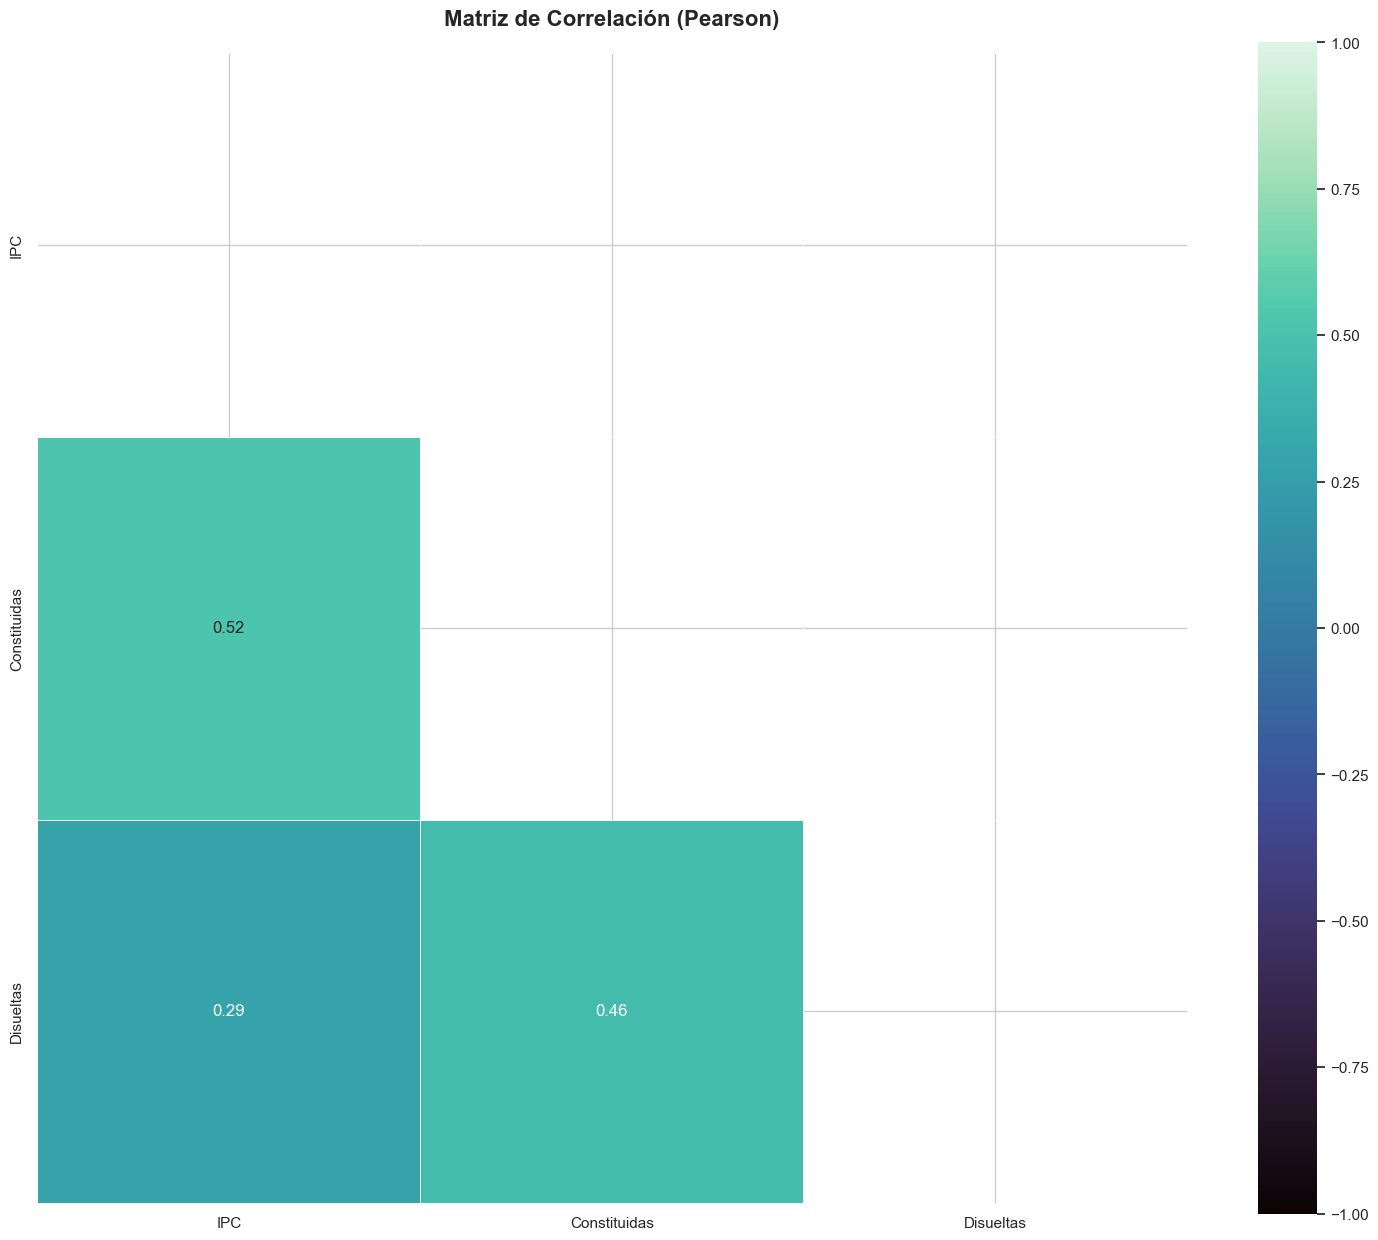

,IPC,Constituidas,Disueltas
IPC,1.000000,0.521535,0.287747
Constituidas,0.521535,1.000000,0.458652
Disueltas,0.287747,0.458652,1.000000


In [6]:
df_heatmap = df_corr[['valor_ipc', 'constituidas', 'disueltas']].copy()
df_heatmap.columns = ['IPC', 'Constituidas', 'Disueltas']

matriz_correlacion_visual(df_heatmap, metodo='pearson', cmap='mako')

### 6. Análisis de Lag (1-3 meses)

Evalúa si el IPC **anticipa** o **retrasa** la actividad empresarial, desplazando las series de empresas 1, 2 y 3 meses hacia el futuro/pasado.

In [7]:
lags = [1, 2, 3]
resultados_lag = []

for lag in lags:
    # IPC vs constituidas desplazada (constituidas de hace N meses vs IPC actual)
    col_const_lag = f'constituidas_lag{lag}'
    col_dis_lag = f'disueltas_lag{lag}'

    df_corr[col_const_lag] = df_corr['constituidas'].shift(lag)
    df_corr[col_dis_lag] = df_corr['disueltas'].shift(lag)

    # Pearson con valores válidos
    pearson_const = df_corr[['valor_ipc', col_const_lag]].dropna().corr().iloc[0, 1]
    spearman_const = df_corr[['valor_ipc', col_const_lag]].dropna().corr(method='spearman').iloc[0, 1]
    pearson_dis = df_corr[['valor_ipc', col_dis_lag]].dropna().corr().iloc[0, 1]
    spearman_dis = df_corr[['valor_ipc', col_dis_lag]].dropna().corr(method='spearman').iloc[0, 1]

    resultados_lag.append({
        'Lag (meses)': lag,
        'IPC vs Constituidas (Pearson)': round(pearson_const, 4),
        'IPC vs Constituidas (Spearman)': round(spearman_const, 4),
        'IPC vs Disueltas (Pearson)': round(pearson_dis, 4),
        'IPC vs Disueltas (Spearman)': round(spearman_dis, 4)
    })

df_lags = pd.DataFrame(resultados_lag)
print('Interpretación: un lag positivo significa que el IPC actual se compara con la actividad empresarial de hace N meses.')
print('Si la correlación aumenta con el lag, el IPC podría "anticipar" la actividad empresarial.\n')
df_lags

Interpretación: un lag positivo significa que el IPC actual se compara con la actividad empresarial de hace N meses.
Si la correlación aumenta con el lag, el IPC podría "anticipar" la actividad empresarial.



,Lag (meses),IPC vs Constituidas (Pearson),IPC vs Constituidas (Spearman),IPC vs Disueltas (Pearson),IPC vs Disueltas (Spearman)
0,1,0.5209,0.4221,0.2823,0.2880
1,2,0.5027,0.4103,0.2885,0.2804
2,3,0.4935,0.4129,0.3022,0.2989


In [8]:
# Resumen: dirección de la mejor correlación por lag
print('=== Resumen de direcciones de lag ===')
print()

# Correlación directa (sin lag)
p0_const = df_corr[['valor_ipc', 'constituidas']].dropna().corr().iloc[0, 1]
p0_dis = df_corr[['valor_ipc', 'disueltas']].dropna().corr().iloc[0, 1]
print(f'IPC vs Constituidas (sin lag):  r = {p0_const:.4f}')
print(f'IPC vs Disueltas (sin lag):     r = {p0_dis:.4f}')
print()

for _, row in df_lags.iterrows():
    lag = int(row['Lag (meses)'])
    p_c = row['IPC vs Constituidas (Pearson)']
    p_d = row['IPC vs Disueltas (Pearson)']
    print(f'IPC vs Constituidas (lag {lag}m): r = {p_c:.4f}  |  IPC vs Disueltas (lag {lag}m): r = {p_d:.4f}')

print()
print('Si la correlación con lag es más fuerte que sin lag, indica que el IPC se relaciona mejor con la actividad empresarial pasada.')

=== Resumen de direcciones de lag ===

IPC vs Constituidas (sin lag):  r = 0.5215
IPC vs Disueltas (sin lag):     r = 0.2877

IPC vs Constituidas (lag 1m): r = 0.5209  |  IPC vs Disueltas (lag 1m): r = 0.2823
IPC vs Constituidas (lag 2m): r = 0.5027  |  IPC vs Disueltas (lag 2m): r = 0.2885
IPC vs Constituidas (lag 3m): r = 0.4935  |  IPC vs Disueltas (lag 3m): r = 0.3022

Si la correlación con lag es más fuerte que sin lag, indica que el IPC se relaciona mejor con la actividad empresarial pasada.


### 7. Scatter plots con línea de tendencia

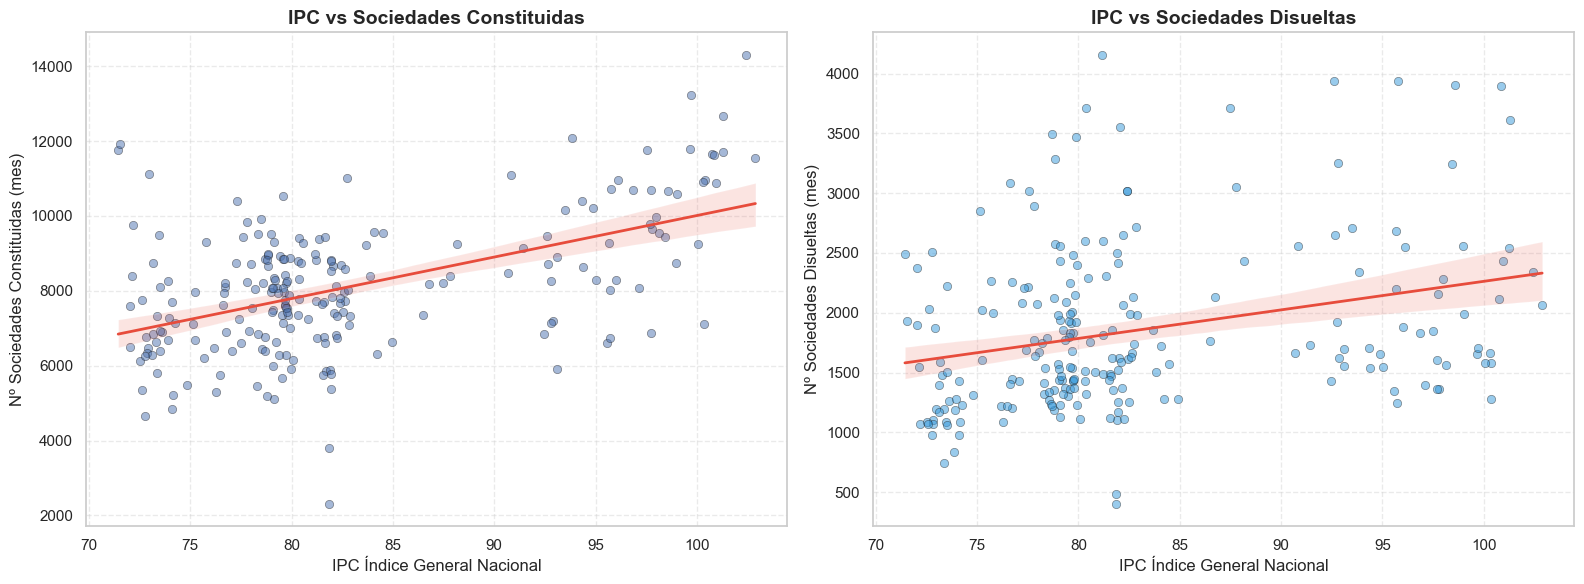

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IPC vs Constituidas
sns.regplot(data=df_corr, x='valor_ipc', y='constituidas',
            scatter_kws={'alpha': 0.5, 'edgecolors': 'k', 'linewidths': 0.5},
            line_kws={'color': '#e74c3c', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title('IPC vs Sociedades Constituidas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('IPC Índice General Nacional', fontsize=12)
axes[0].set_ylabel('Nº Sociedades Constituidas (mes)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)

# IPC vs Disueltas
sns.regplot(data=df_corr, x='valor_ipc', y='disueltas',
            scatter_kws={'alpha': 0.5, 'edgecolors': 'k', 'linewidths': 0.5, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('IPC vs Sociedades Disueltas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('IPC Índice General Nacional', fontsize=12)
axes[1].set_ylabel('Nº Sociedades Disueltas (mes)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 8. Conclusiones

In [12]:
print('=' * 70)
print('RESUMEN DEL ANÁLISIS DE CORRELACIÓN: IPC vs ACTIVIDAD EMPRESARIAL')
print('=' * 70)
print()

print(f'Periodo analizado: {df_corr["id_tiempo"].min()} – {df_corr["id_tiempo"].max()}')
print(f'Registros: {len(df_corr)} meses')
print()

print('--- Correlación directa (sin lag) ---')
print(f'IPC vs Constituidas:  Pearson = {result_const["pearson"]:.4f} | Spearman = {result_const["spearman"]:.4f}')
print(f'  → Recomendado: {result_const["recomendacion"].upper()} ({result_const["valor_recomendado"]:.4f})')
print(f'  → Fuerza: {result_const["fuerza"]} {result_const["direccion"]}')
print()
print(f'IPC vs Disueltas:     Pearson = {result_dis["pearson"]:.4f} | Spearman = {result_dis["spearman"]:.4f}')
print(f'  → Recomendado: {result_dis["recomendacion"].upper()} ({result_dis["valor_recomendado"]:.4f})')
print(f'  → Fuerza: {result_dis["fuerza"]} {result_dis["direccion"]}')
print()

print('--- Análisis de Lag ---')
best_const_lag = df_lags.loc[df_lags['IPC vs Constituidas (Pearson)'].abs().idxmax()]
best_dis_lag = df_lags.loc[df_lags['IPC vs Disueltas (Pearson)'].abs().idxmax()]
print(f'Mejor correlación IPC vs Constituidas: lag = {int(best_const_lag["Lag (meses)"])} meses (r = {best_const_lag["IPC vs Constituidas (Pearson)"]:.4f})')
print(f'Mejor correlación IPC vs Disueltas:    lag = {int(best_dis_lag["Lag (meses)"])} meses (r = {best_dis_lag["IPC vs Disueltas (Pearson)"]:.4f})')
print()

print('=' * 70)

RESUMEN DEL ANÁLISIS DE CORRELACIÓN: IPC vs ACTIVIDAD EMPRESARIAL

Periodo analizado: 200801 – 202604
Registros: 220 meses

--- Correlación directa (sin lag) ---
IPC vs Constituidas:  Pearson = 0.5215 | Spearman = 0.4147
  → Recomendado: SPEARMAN (0.4147)
  → Fuerza: moderada positiva

IPC vs Disueltas:     Pearson = 0.2877 | Spearman = 0.3129
  → Recomendado: PEARSON (0.2877)
  → Fuerza: débil positiva

--- Análisis de Lag ---
Mejor correlación IPC vs Constituidas: lag = 1 meses (r = 0.5209)
Mejor correlación IPC vs Disueltas:    lag = 3 meses (r = 0.3022)

